# AI AgriYield Predictor
## Milestone 1: Requirements & Dataset Preparation

**Project Objective**: Develop a machine learning model to predict crop yield (kg per acre) using soil nutrients, weather conditions, fertilizer usage, and weather-related features.

**Target Variable**: `Yield_kg_per_acre` (Continuous Regression Task)

### Step 1: Environment Setup & Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

%matplotlib inline

### Step 2: Data Exploration
Loading the dataset and examining its structure, data types, and initial records.

In [2]:
df = pd.read_csv("dataset.csv")
df.head()

,State,Crop,Soil_Type,Fertilizer,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
0,Karnataka,Soybean,Loamy,DAP,56,41,51,120,31.06,1839,6.82,2003
1,Odisha,Cotton,Red Soil,Urea,29,36,112,247,33.97,1062,6.41,2002
2,Punjab,Groundnut,Red Soil,Compost,37,38,177,142,24.21,1463,7.06,2015
3,Gujarat,Wheat,Red Soil,Compost,58,77,129,227,30.85,2373,5.93,2022
4,Andhra Pradesh,Cotton,Clay,Organic,108,61,63,263,37.03,1497,6.24,2017


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   State               1500 non-null   str    
 1   Crop                1500 non-null   str    
 2   Soil_Type           1500 non-null   str    
 3   Fertilizer          1500 non-null   str    
 4   N                   1500 non-null   int64  
 5   P                   1500 non-null   int64  
 6   K                   1500 non-null   int64  
 7   Rainfall_mm         1500 non-null   int64  
 8   Temperature_C       1500 non-null   float64
 9   Yield_kg_per_acre   1500 non-null   int64  
 10  Soil_pH             1500 non-null   float64
 11  Year                1500 non-null   int64  
dtypes: float64(2), int64(6), str(4)
memory usage: 140.8 KB


In [4]:
df.describe()

,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,73.979333,59.894667,106.120667,178.887333,27.868007,3911.834667,6.737780,2012.093333
std,38.126404,33.282699,54.133647,71.437279,5.729707,9928.185123,0.724168,7.301244
min,10.000000,5.000000,10.000000,50.000000,18.000000,509.000000,5.500000,2000.000000
25%,42.000000,30.000000,61.000000,118.000000,22.977500,1416.500000,6.100000,2006.000000
50%,72.000000,59.000000,107.000000,181.000000,27.715000,2044.500000,6.730000,2012.000000
75%,108.000000,89.000000,154.000000,240.000000,32.705000,3040.000000,7.390000,2018.000000
max,139.000000,119.000000,199.000000,299.000000,37.980000,88455.000000,8.000000,2024.000000


**Observations:**
- Dataset contains 1500 rows and 12 columns.
- No missing values were found.
- Data types were appropriate for processing.
- Yield variable showed slight skewness due to some high maximum values.

### Step 3: Data Cleaning
Checking for null values and duplicate records.

In [5]:
df.isnull().sum()

State                0
Crop                 0
Soil_Type            0
Fertilizer           0
N                    0
P                    0
K                    0
Rainfall_mm          0
Temperature_C        0
Yield_kg_per_acre    0
Soil_pH              0
Year                 0

In [6]:
duplicates = df.duplicated().sum()
print("Duplicate records:", duplicates)

Duplicate records: 0


**Results:**
- No missing values
- No duplicate records

Thus, no additional cleaning was required.

### Data Analysis (Graphs)
#### Graph 1: Distribution of Crop Yield

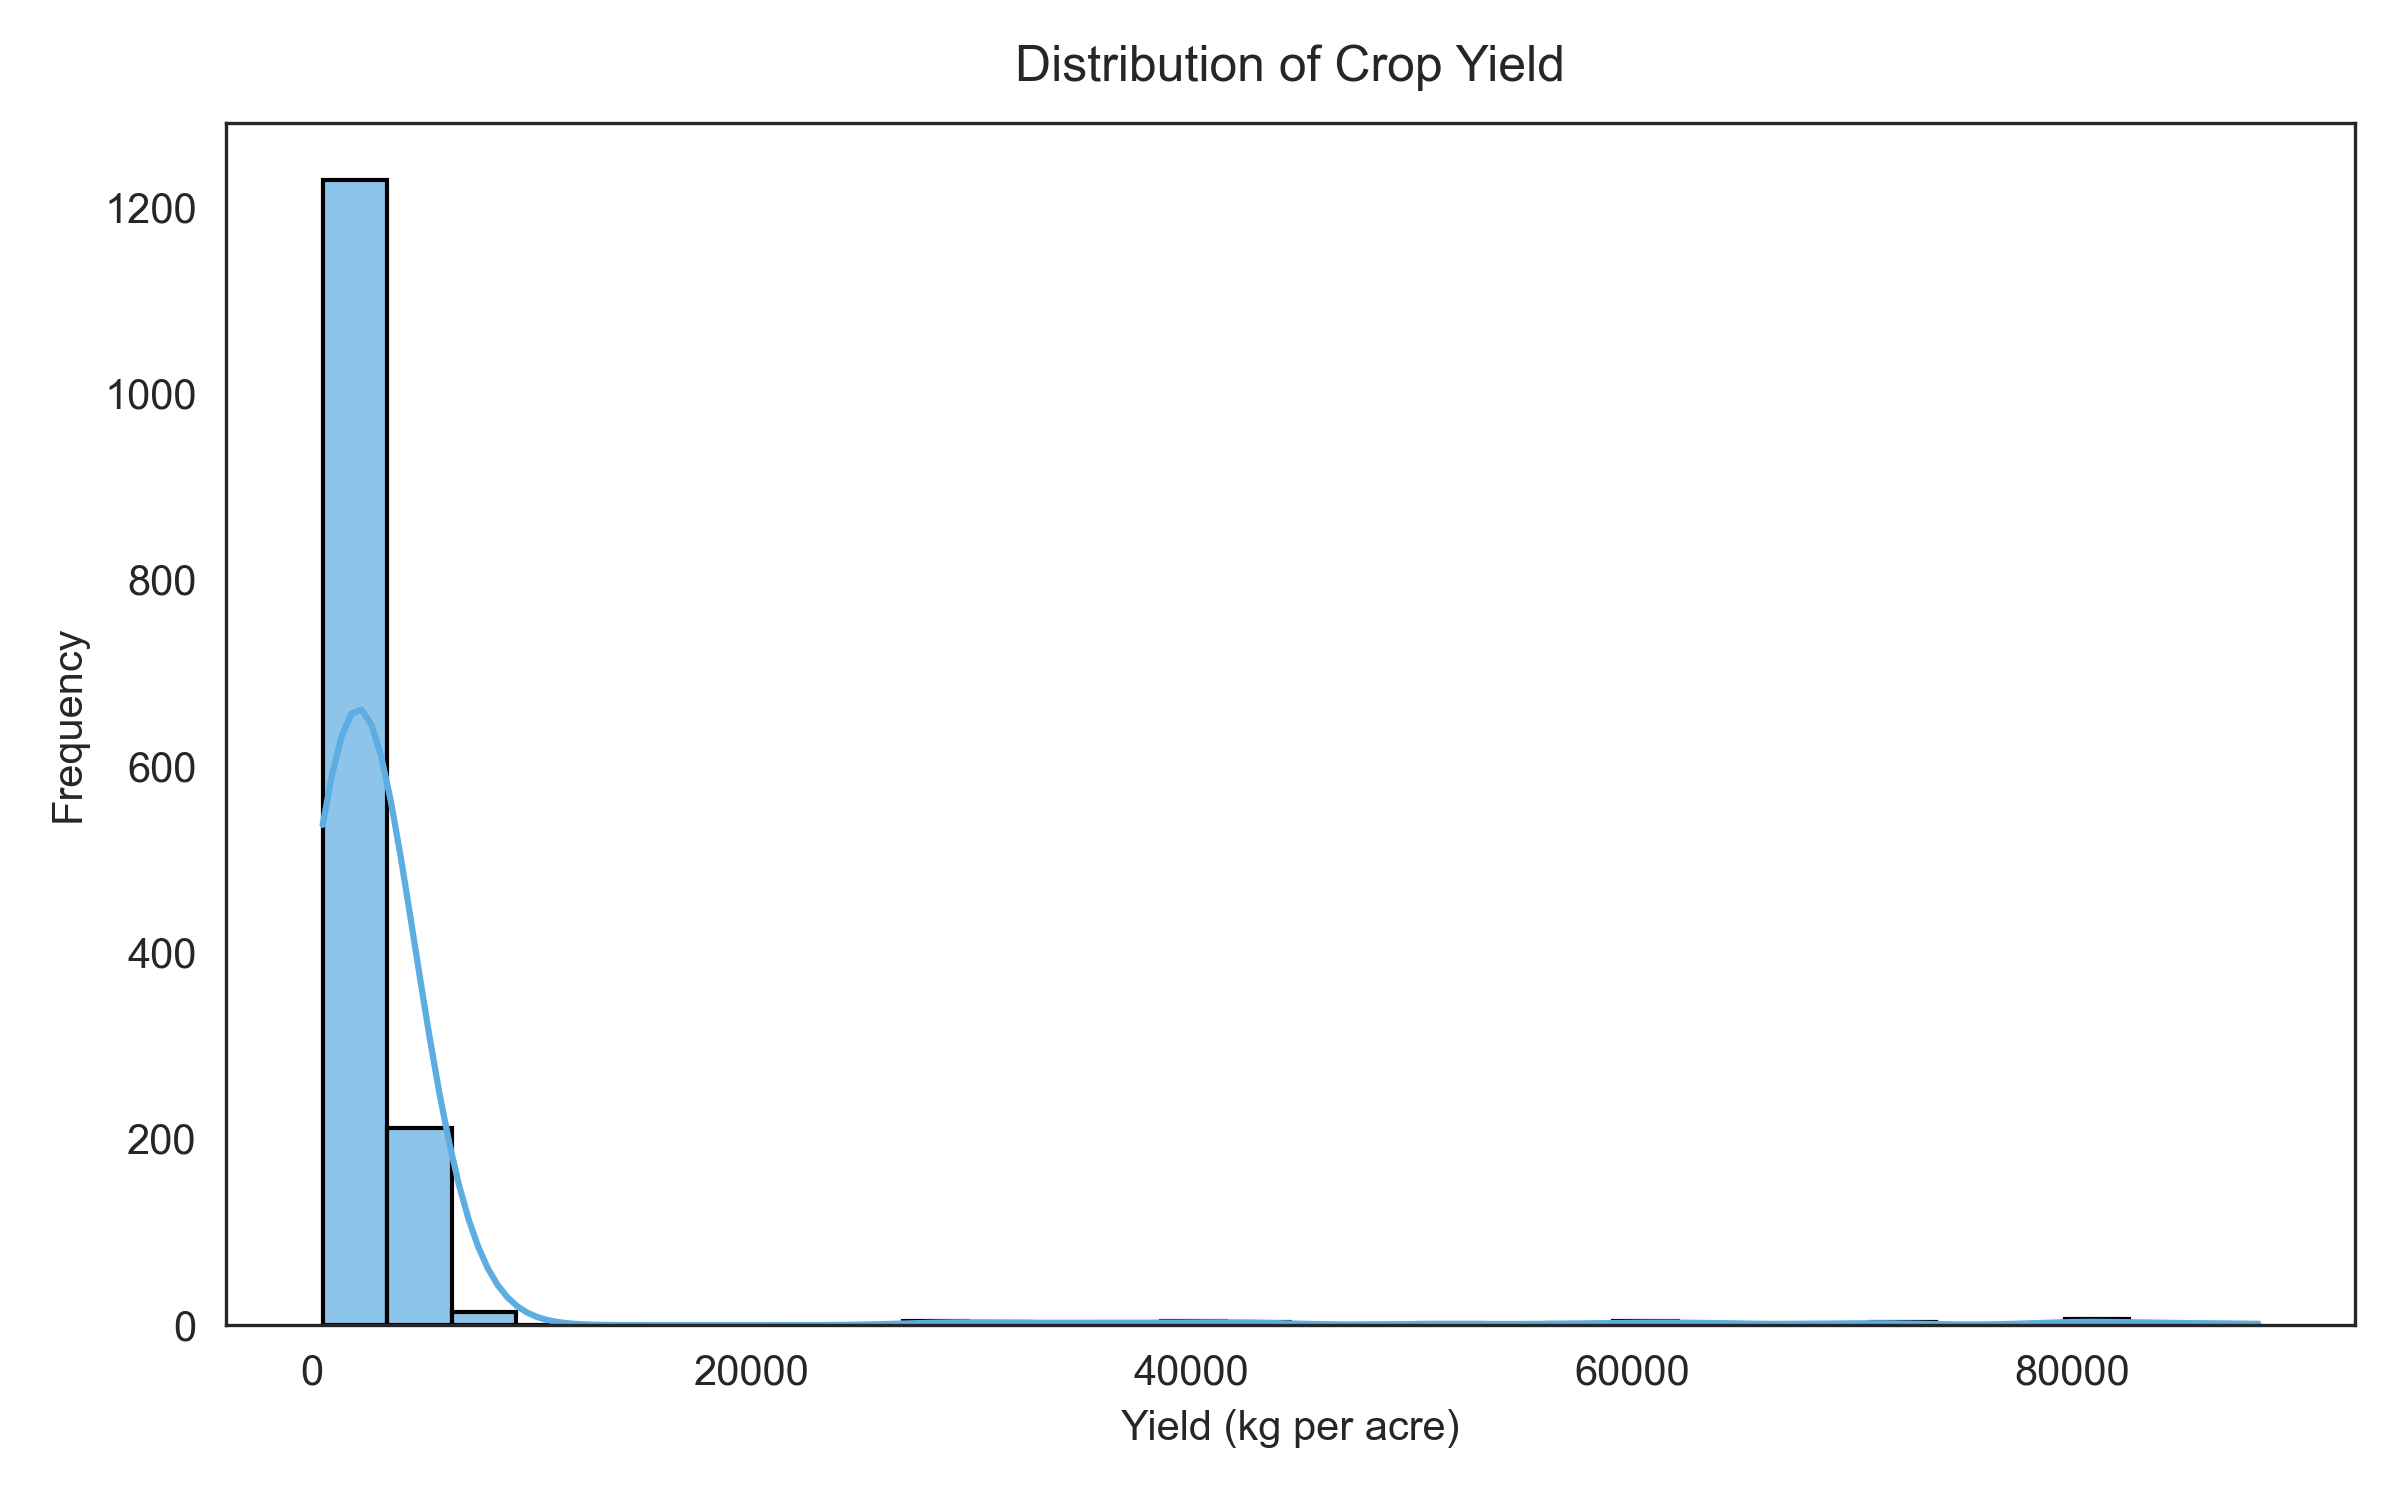

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Yield_kg_per_acre'], bins=30, kde=True)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (kg per acre)")
plt.ylabel("Frequency")
plt.show()

**Observation:**
- The yield distribution is slightly right-skewed.
- Some crops have significantly higher yield values compared to the majority.
- Most yield values fall within a moderate range.

#### Graph 2: Correlation Heatmap

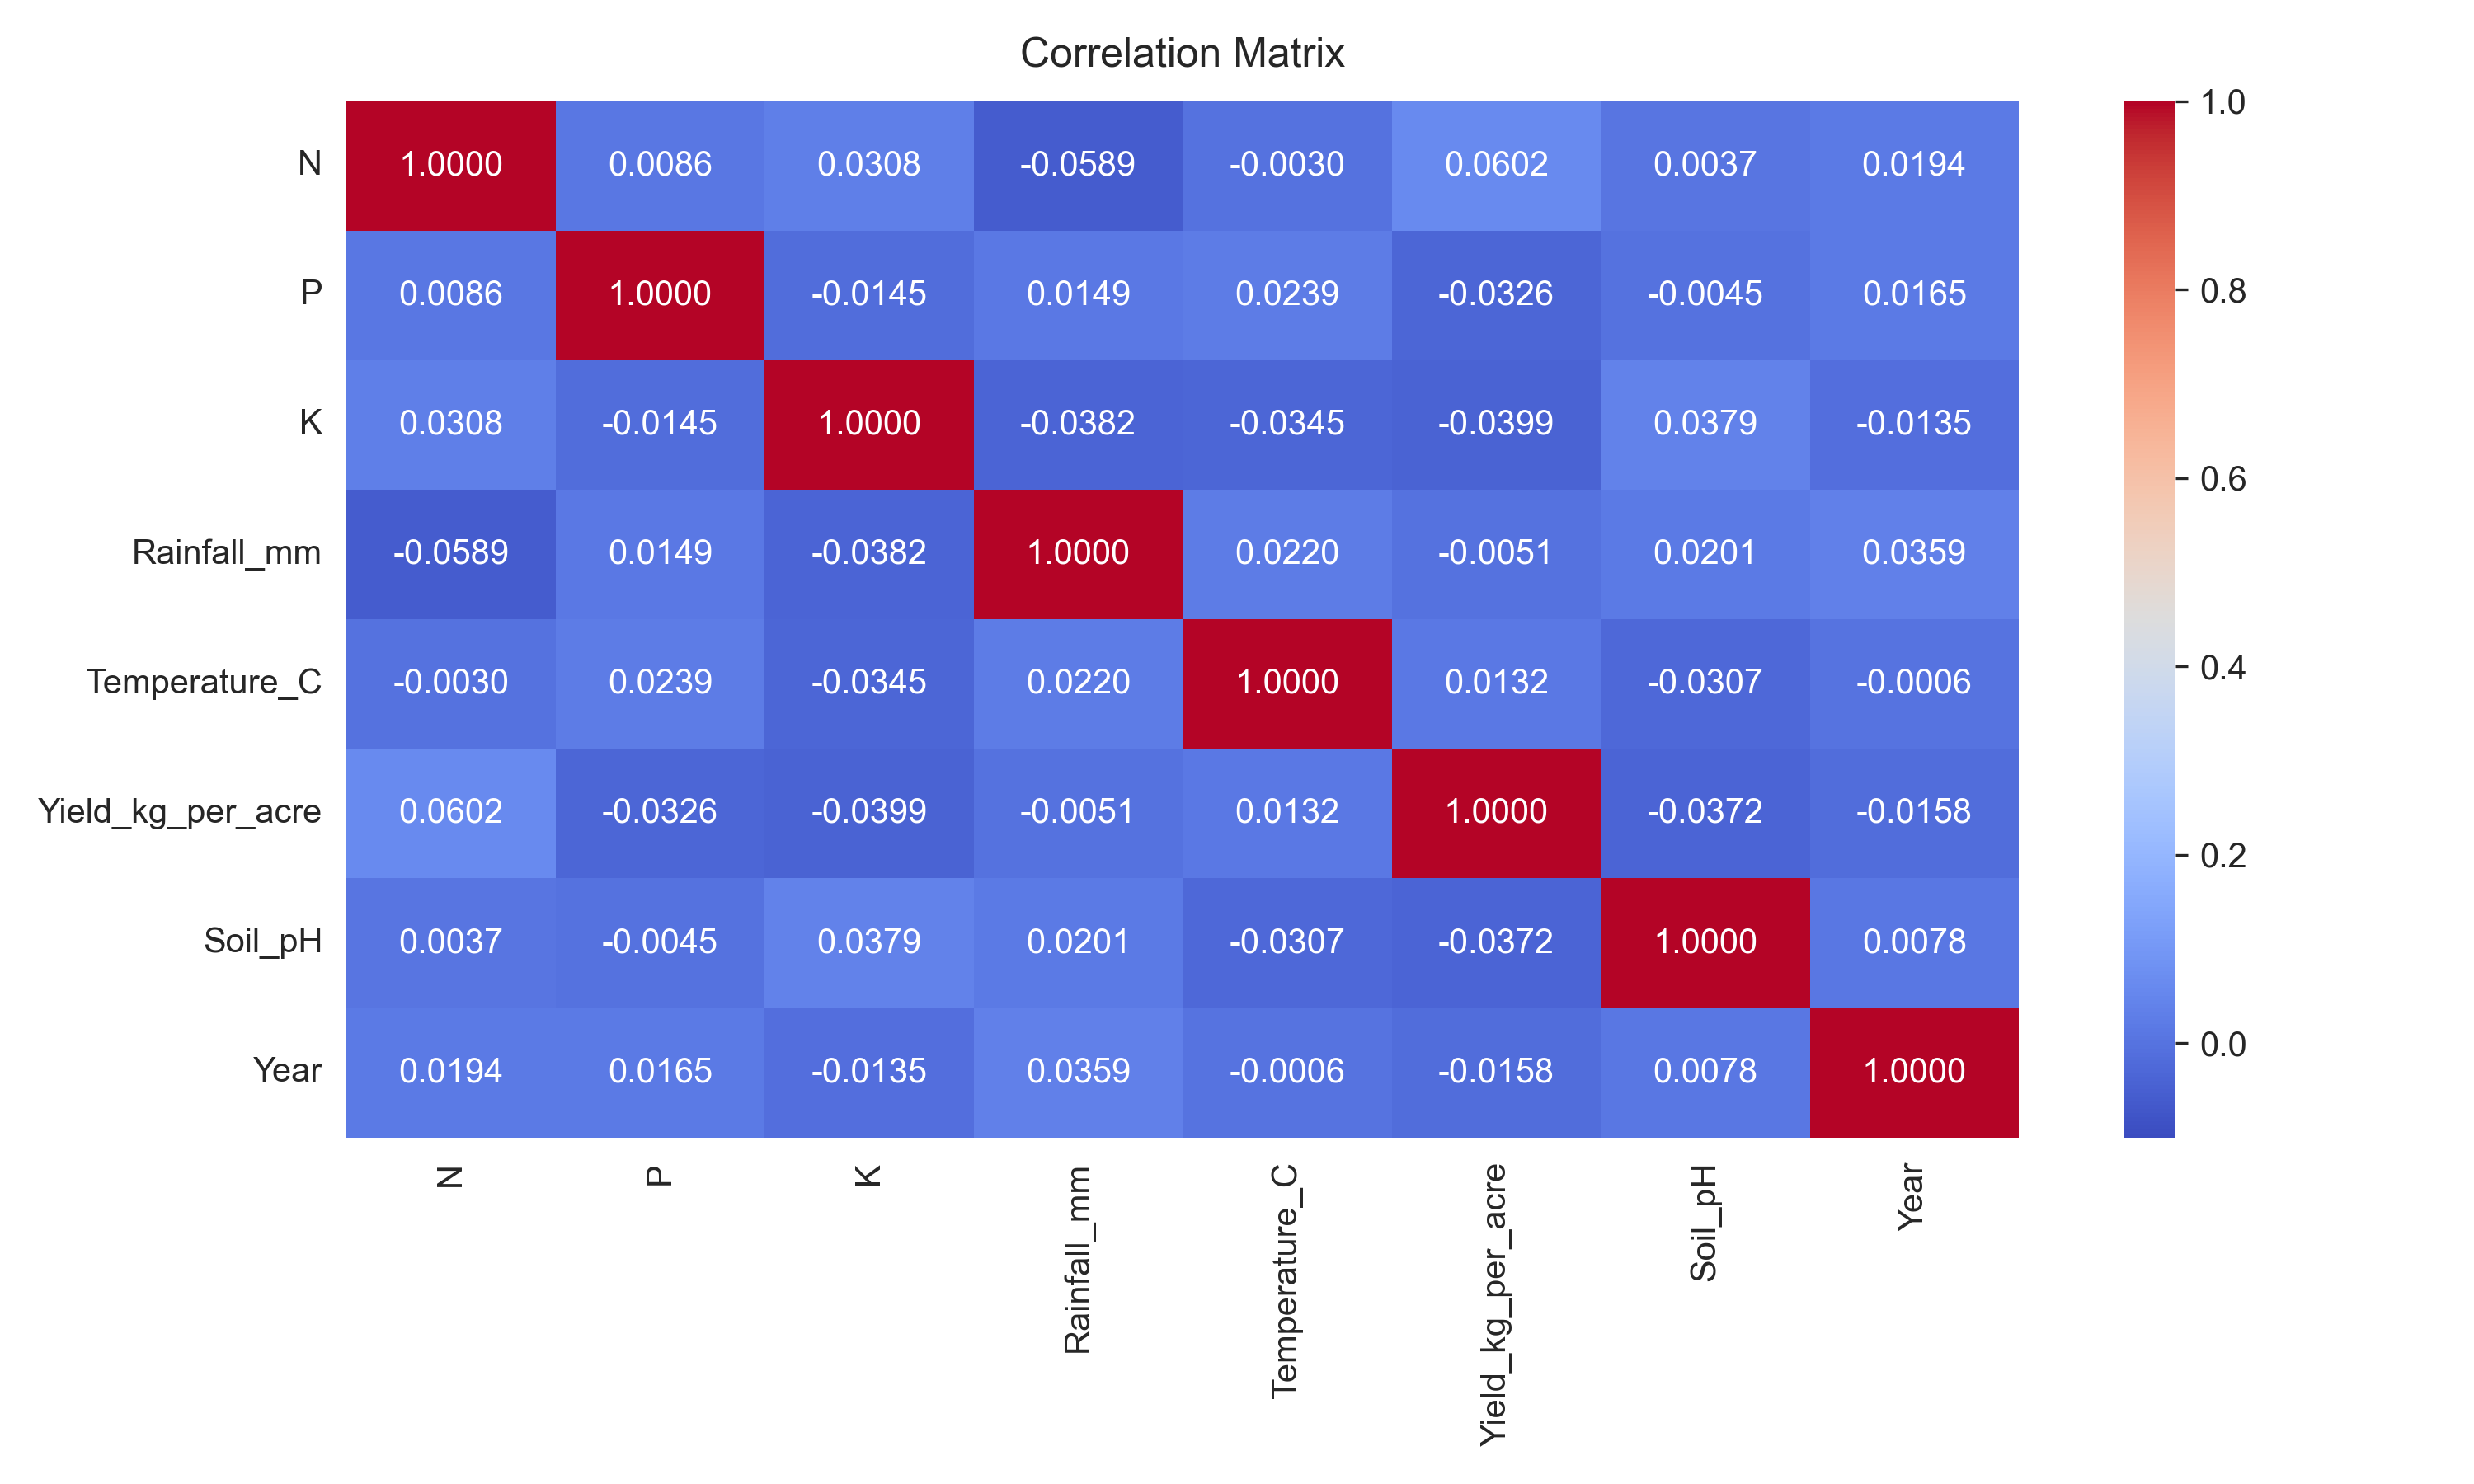

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Observation:**
- The heatmap shows relationships between numerical features.
- Some soil nutrients and rainfall show correlation with yield.
  - Helps in understanding which features may influence crop productivity.

### Feature Engineering
#### One-Hot Encoding
Since machine learning models cannot process categorical text data directly, categorical features were converted using one-hot encoding:

In [9]:
X = df.drop("Yield_kg_per_acre", axis=1)
y = df["Yield_kg_per_acre"]
X_encoded = pd.get_dummies(X, drop_first=True)

The dataset was split into features (X) and target variable (y) before applying encoding.

**Result:**
- Number of features increased from 12 to 39.
- All categorical variables were converted into numerical format.

#### Feature Scaling
Numerical features had different ranges (e.g., rainfall in hundreds, pH in single digits). To ensure uniform scaling of numerical features, StandardScaler was applied only to the following columns:

In [10]:
scaler = StandardScaler()
numerical_cols = ['N', 'P', 'K', 'Rainfall_mm', 'Temperature_C', 'Soil_pH', 'Year']
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])
print("Final dataset shape after preprocessing:", X_encoded.shape)

Final dataset shape after preprocessing: (1500, 39)


**After scaling:**
- Numerical features were standardized (mean = 0, std = 1)
- Dataset shape became (1500, 39)
- No rows were lost during preprocessing

### Challenges Faced
1. Initial virtual environment activation issues.
2. Execution delay due to kernel configuration.
3. Understanding the correct order of preprocessing steps.

These were resolved through proper environment setup and debugging.

### Outcome of Milestone 1
- Dataset was explored and understood.
- No missing or duplicate data.
- Categorical features were encoded.
- Numerical features were standardized.
- 2 important visualizations were generated.
- Final dataset prepared for regression model training.

### Conclusion
Milestone 1 successfully completed dataset preparation and preprocessing steps required for machine learning. The data is now clean, structured, encoded, and scaled, making it ready for building regression models in the next milestone.

---

### Submitted by:
**Bandi Siri**  
siribandi17@gmail.com